# Introducrtion to Machine Learning: Assignment #1
## Submission date: 16\12\2024, 23:59.
### Topics:
- Linear regression
- Gaussian Bayes
- Naïve bayes
- KNN

Submitted by:

Lian Natour 207300443

**Assignment Instruction:**

· Submissions in pairs only.

· Try to keep the code as clean, concise, and short as possible

· If you wish to work in your IDE, you can, but you **must**,  insert the script back to the matching cells of the notebook and run the code. <br/>Only the notebook will be submitted in moodle (in `.ipynb` format).

· <font color='red'>Please write your answers to question in red</font>.

**Important:** All plots, results and outputs should be included in the notebook as the cells' outputs (run all cells and do not clear the output). <br/>

**Important:** Your submission must be entirely your own. Any attempts of plagiarism (including ChatGPT) will lead to grade 0 and disciplinary actions.

## Customizing Colab
This is an optional section for you convenience:<br/>
Go to Tools -> Settings -> editor<br/>
There, you can adjust fonts, add line numbers, change indentations.

## Question 1 - Linear regression
In this exercise you will implement linear regression alone!

The dataset consists of a few 1-feature samples $\{(x_i,y_i )\}_{i=1}^∞$ where $y_i$ is the prediction of the $x_i\in\mathbb{R}$ sample. <br/>
We will only try to fit the given data, <u>without validation or test</u>.<br/>
We define the following:
-	X, 2d matrix from size n x d which represents the training samples.
-	Y, array from size n which represents the target value for the corresponding sample.


import libarires

In [303]:
import numpy as np
import matplotlib.pyplot as plt

Implement the function Linreg_sol(X,Y) which outputs the closed form solution for linear regression on X,Y. <br/>Assume that the data is already zero-centered

In [304]:

# X: (n,d) array
# Y: (n,) array
# Output: (d,) array of weights

def Linreg_sol(X, Y):
   # Calculate the dot product of the transpose of X and X
    X_transpose_Mul_X = np.dot(X.T, X)

    # Calculate the dot product of the transpose of X and  y
    X_transpose_Mul_y = np.dot(X.T, Y)

    # find the regression coefficients
    coefficients = np.linalg.solve(X_transpose_Mul_X, X_transpose_Mul_y)

    return coefficients

First visualization

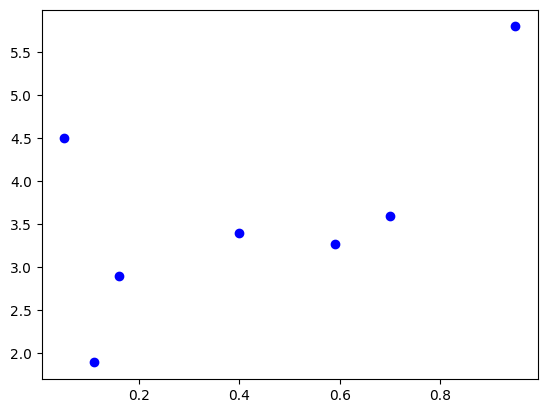

In [305]:
data = np.array([[0.4, 3.4], [0.95, 5.8], [0.16, 2.9], [0.7, 3.6], [0.59, 3.27], [0.11, 1.89], [0.05, 4.5]])
plt.scatter(data[:,0], data[:,1], color='blue', label='Data')
plt.show()

Split the data to X,Y.<br/>
Since the data is non-zero centered, center it to mean zero (since we discussed only y=wx). Then, run the solution.

In [306]:
# Split data into X and Y
X = data[:, 0:1]
Y = data[:, 1]
 # Calculate means and center the data
mean_X = np.mean(X)
mean_Y = np.mean(Y)
X_centered = X - mean_X
Y_centered = Y - mean_Y
mean = np.array([mean_X, mean_Y])
w = Linreg_sol(X_centered, Y_centered)

# Restore the original line.
# As discussed, if y'=wx' (after centralization) than y-u_y = w(x-u_x), isolate y.

print(f'The linear line is y={w[0].item():.2f}*(x-{mean[0].item():.2f})+{mean[1].item():.2f}')

The linear line is y=2.17*(x-0.42)+3.62


Plot the line solution <br/>
Does the line really fit the data? <br/>
<font color='red'>The linear regression line generally shows how Y increases as X increases, which is a good estimate for how X and Y relate. It fits well with many of the main data points, but some points, especially at the far ends, don’t follow this trend closely. This means the model might not be capturing everything that affects the changes in the data.</font>

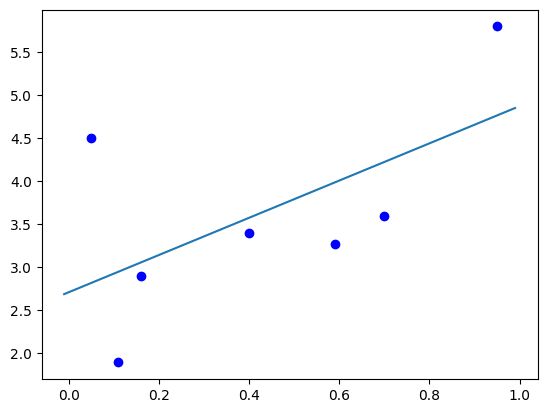

In [307]:
x = np.arange(-0.01, 1, 0.01)
y = w * (x - mean[0]) + mean[1]
plt.plot(x,y)

plt.scatter(data[:,0], data[:,1], color='blue', label='Data')
plt.show()

We define the deviation of the data to the fitter line as:
$$ s=\sqrt{Var(SSE)}=\sqrt{\frac{\sum_{i=1}^n (y_i-f(x_i))^2}{n-1}} $$

Then, a point in the dataset defined as an outlier if its distance from the fitted line is more than one deviation s.<br/>
Find and print the outliers from the dataset


In [308]:
# Implement here and print the points that are outliers.
# Calculate the predicted values
predicted_y = w[0] * (X - mean[0]) + mean[1]

# Calculate residuals
residuals = Y - predicted_y.reshape(-1)

# Compute standard deviation of residuals
std_dev = np.sqrt(np.var(residuals, ddof=1))

# Identify outliers
outliers = np.abs(residuals) > std_dev

# Print indices and values of outliers
outlier_indices = np.where(outliers)[0]
print("Outlier indices:", outlier_indices)
print("Outlier values:", data[outliers])

Outlier indices: [1 5 6]
Outlier values: [[0.95 5.8 ]
 [0.11 1.89]
 [0.05 4.5 ]]


Run the linear regression again, but remove the outliers <br/>
Is the result better? Why?<br/>
<font color='red'>The result is better because removing the outliers makes the line fit the remaining points more closely. The line now shows the overall trend of the data more accurately without being affected by extreme values.</font>

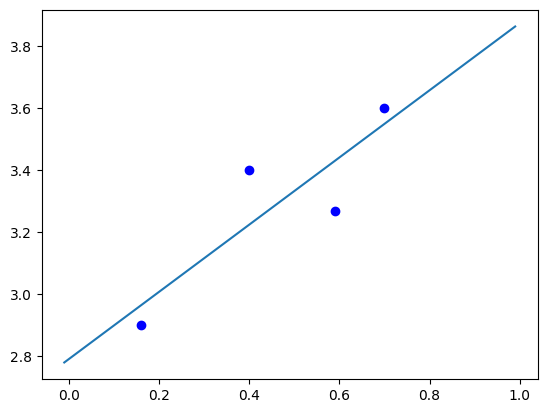

In [309]:
# modify the following row by removing the outliers
data = np.array([[0.4, 3.4], [0.16, 2.9], [0.7, 3.6], [0.59, 3.27]])
# Split data into X and Y
X = data[:, 0:1]
Y = data[:, 1]

# Calculate means and center the data
mean_X = np.mean(X)
mean_Y = np.mean(Y)
X_centered = X - mean_X
Y_centered = Y - mean_Y
mean = np.array([mean_X, mean_Y])
w = Linreg_sol(X_centered, Y_centered)

x = np.arange(-0.01, 1, 0.01)
y = w * (x - mean[0]) + mean[1]
plt.plot(x,y)

plt.scatter(data[:,0], data[:,1], color='blue', label='Data')
plt.show()

## Question 2 - Gaussian bayes
You are given a dataset represents customer behavior data collected from a retail company. The three classes represent different types of customers: infrequent buyers, occasional buyers, and frequent buyers. The features include 10 various customer features. <br/>
Since the data is continuous, you will implement Gaussian bayes and compare to Gaussian naïve bayes.

import libarires

In [310]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Load the customers dataset from https://sharon.srworkspace.com/ml/datasets/hw1/customers.csv

In [311]:
# Implement here
df = pd.read_csv("https://sharon.srworkspace.com/ml/datasets/hw1/customers.csv")
print(df.shape)
df.head(5)

(1000, 11)


,average_spending,frequency_of_visits,promotion_responsiveness,customer_age,loyalty_score,preferred_category,last_purchase_interval,average_basket_size,store_affinity,online_vs_instore_ratio,label
0,-0.221948,-1.120637,2.196646,0.553293,0.767479,-1.226179,1.887976,0.681743,-1.140045,0.962503,2
1,1.858383,-3.680880,0.227496,-3.818368,0.635968,1.609521,-0.153135,-0.474178,1.341139,-0.771772,2
2,0.558890,-1.725818,0.585904,-1.718041,-0.736770,-1.406815,0.768721,-0.322028,-0.319243,1.325432,2
3,0.428417,-1.801396,2.015275,-1.559837,1.290644,-1.889649,1.195451,0.363116,-0.694916,0.311110,2
4,-0.131161,-2.079008,1.483744,1.636858,-0.734811,-0.640154,2.666422,-1.085748,-0.892851,0.029796,2


Check if there is even potential for gaussian assumption to work here, by plotting the<br/>density of the features <u>only</u>, using plotting for data frames. <br/>
Will gaussian bayes work here or not? <br/>
<font color='red'>The Gaussian Bayes assumption will partially work here because many features have distributions close to Gaussian.
But,some features (customer_age, label) deviate from the Gaussian shape, which might reduce the model's accuracy for these particular features.</font>

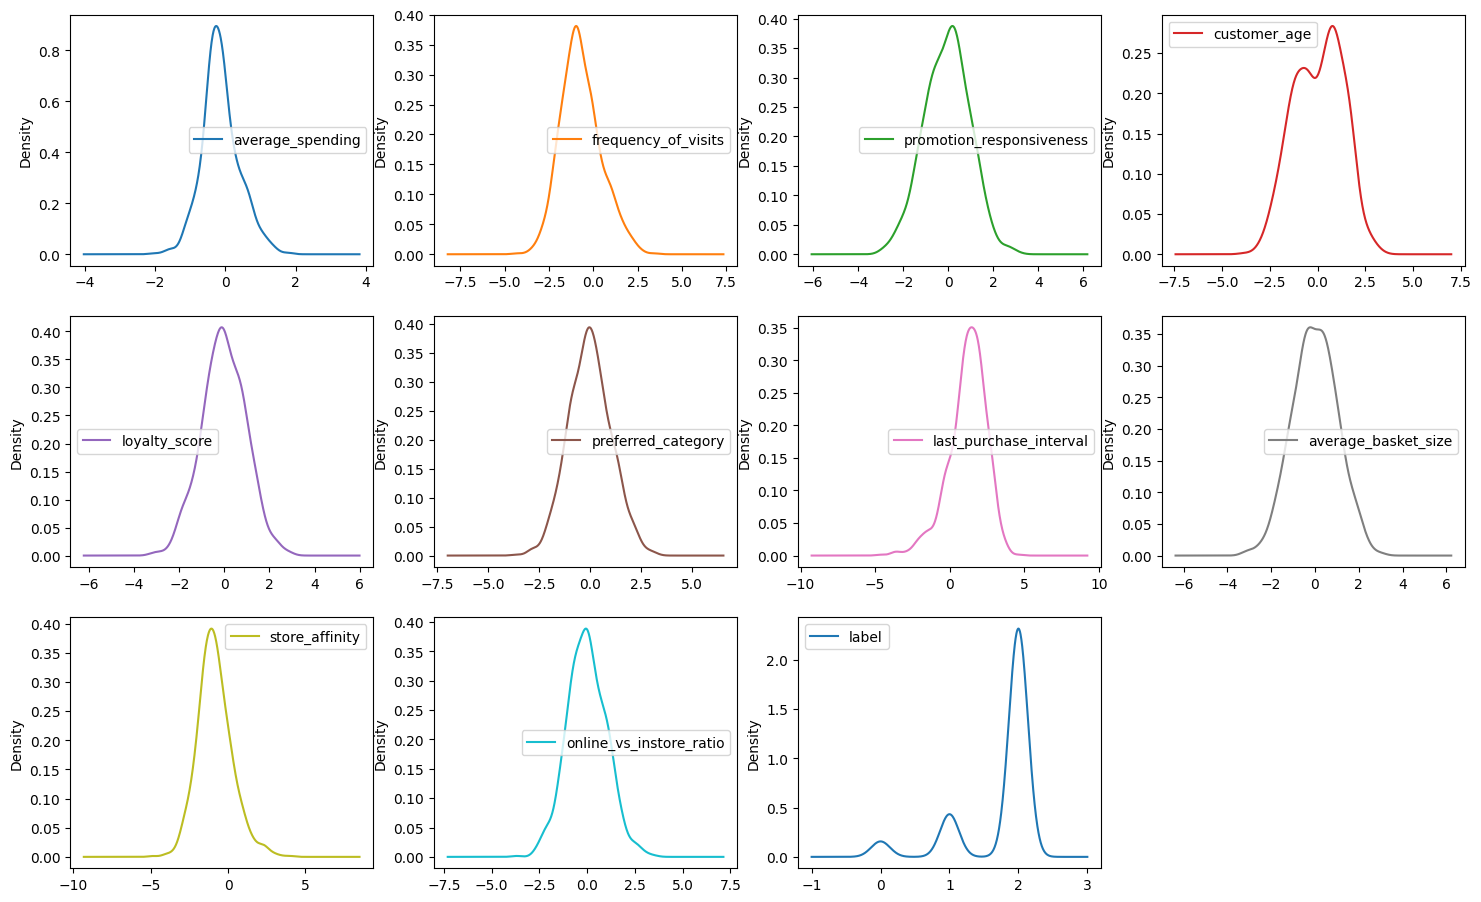

In [312]:
df.plot(kind='density', subplots=True, layout=(4,4), figsize=(18, 15), sharex=False)
plt.show()

Convert the data to numpy and split the data to 80% training and 20% test with random state of 42. <br/>Make sure to maintain the dataset balanced, using stratify=y, in train_test_split method.
<br/>Note that the data frame currently includes the labels as well.

In [313]:
# Separate the features (X) and labels (y)
X = df.drop(columns=['label'])  # Features (all columns except 'label')
y = df['label']                 # Target (label column)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,            # Features and labels
    test_size=0.2,   # 20% for testing, 80% for training
    random_state=42, # Ensures reproducibility
    stratify=y       # Maintains class balance in train/test splits
)

# Print shapes to confirm
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (800, 10)
Testing Features Shape: (200, 10)
Training Labels Shape: (800,)
Testing Labels Shape: (200,)


Implement the functions below. <br/>Both get train and test data $X\in\mathbb{R}^{n\times d}$. <br/>
Both return the predicted classes (vector sized n), but the naïve bayes assumes that the features are independent.<br/>
Hint for efficient implementation: you don't need more than one loop, use numpy!

In [316]:
import numpy as np

# Function to compute class-wise statistics (mean, prior, covariance/variance)
def compute_class_statistics(train, y_train, mode="full"):

    class_labels = np.unique(y_train)  # Get unique class labels
    num_features = train.shape[1]  # Number of features (columns)
    stats = {}  # Dictionary to store computed statistics

    # Compute means and priors for all classes
    stats["means"] = [np.mean(train[y_train == cls], axis=0) for cls in class_labels]
    stats["priors"] = [np.sum(y_train == cls) / len(y_train) for cls in class_labels]

    if mode == "full":
        # Compute full covariance matrices for Gaussian Bayes
        stats["covariances"] = [np.cov(train[y_train == cls], rowvar=False) + 1e-5 * np.eye(num_features)
                                for cls in class_labels]
    elif mode == "naive":
        # Compute feature variances for Naive Bayes
        stats["variances"] = [np.var(train[y_train == cls], axis=0) + 1e-5 for cls in class_labels]

    return stats, class_labels

# Function to compute log-likelihoods for test data
def compute_log_likelihoods(test, stats, class_labels, mode="full"):

    num_samples = test.shape[0]  # Number of test samples
    num_classes = len(class_labels)  # Number of classes
    num_features = test.shape[1]  # Number of features

    log_likelihoods = np.zeros((num_samples, num_classes))  # Initialize log-likelihood array
    log_priors = np.log(stats["priors"])  # Logarithm of class priors

    for idx, cls in enumerate(class_labels):
        mean = stats["means"][idx]  # Mean for the current class
        if mode == "full":
            # For Gaussian Bayes, use full covariance matrix
            cov = stats["covariances"][idx]
            inv_cov = np.linalg.inv(cov)
            det_cov = np.linalg.det(cov)

            diff = test - mean  # Difference between test samples and class mean
            quadratic_term = np.sum(diff @ inv_cov * diff, axis=1)
            normalization_term = np.log((2 * np.pi) ** num_features * det_cov)

            log_likelihoods[:, idx] = -0.5 * (normalization_term + quadratic_term) + log_priors[idx]

        elif mode == "naive":
            # For Naive Bayes, use diagonal variances
            var = stats["variances"][idx]
            log_prob = -0.5 * (np.log(2 * np.pi * var) + ((test - mean) ** 2) / var)
            log_likelihoods[:, idx] = np.sum(log_prob, axis=1) + log_priors[idx]

    return log_likelihoods

# Gaussian Bayes Classifier
def classify_point_gaussian_bayes(train, test):
    global y_train  # Access global labels
    stats, class_labels = compute_class_statistics(train, y_train, mode="full")
    log_likelihoods = compute_log_likelihoods(test, stats, class_labels, mode="full")
    return class_labels[np.argmax(log_likelihoods, axis=1)]  # Return class predictions

# Gaussian Naive Bayes Classifier
def classify_point_gaussian_naive_bayes(train, test):
    global y_train  # Access global labels
    stats, class_labels = compute_class_statistics(train, y_train, mode="naive")
    log_likelihoods = compute_log_likelihoods(test, stats, class_labels, mode="naive")
    return class_labels[np.argmax(log_likelihoods, axis=1)]  # Return class predictions


For both GB and GNB, we will look at train vs test. Run the next cell and answer the following:
- Which model achieved better learning? Why?
- Could the other model be sometimes better? How, for example?

<font color='red'>The Gaussian Bayes (GB) model did better than the Gaussian Naive Bayes (GNB) because GB considers relationships between features, while GNB assumes all features are independent. This makes GNB simpler and faster but less accurate when features are connected. GNB can still work well if the features are truly independent or with small datasets. In this case, GB was more accurate because it captured the feature relationships.</font>
<br/>Hint: Use the next section, for visualization the correlation matrix on the train.  

In [317]:
# Reminder: success rate is the precentage of correctly classified data within the number of all data in the test set.

dict1 = {'GB': [], 'GNB': []}

accs = classify_point_gaussian_bayes(train=x_train, test=x_train)
dict1['GB'].append(np.count_nonzero(accs == y_train) / len(y_train))

accs = classify_point_gaussian_bayes(train=x_train, test=x_test)
dict1['GB'].append(np.count_nonzero(accs == y_test) / len(y_test))

accs = classify_point_gaussian_naive_bayes(train=x_train, test=x_train)
dict1['GNB'].append(np.count_nonzero(accs == y_train) / len(y_train))

accs = classify_point_gaussian_naive_bayes(train=x_train, test=x_test)
dict1['GNB'].append(np.count_nonzero(accs == y_test) / len(y_test))

df = pd.DataFrame(dict1, columns=['GB', 'GNB'], index=['train', 'test'])
print(df)

          GB      GNB
train  0.865  0.83875
test   0.840  0.82000


Sharon, help me! when I tried to apply the gaussian bayes I got an error saying "matrix is singular" | "invalid value encountered in log".

In theory, $\Sigma$, the covariance matrix is proved (in hw0) being PSD (in particullary - positive determinant).

However, practically, due to numerical stability it can have be small, yet negative determinant (for example, -2.383027111200437e-48). One great method for solving this issue, is instead of using $\ln\det\Sigma_c$, using $\ln(\det\Sigma_c+1e-10)$.

From $\ln$ being increasing in $\mathbb{R^+}$, it will not change the classes scores.

Its not enough! We want to get even better test results. <br/>
Please look at the train correlation matrix.
- Choose one feature to remove and explain why you chose it.
- If you continue to remove features, what do you expect to happend with the train error?

<font color='red'>After analyzing the correlation matrix, I noticed that the features "store_affinity" and "last_purchase_interval" are highly correlated.so to reduce redundancy and enhance model performance, I decided to remove the "store_affinity"  because it is more correlated to the rest of the features.</font>

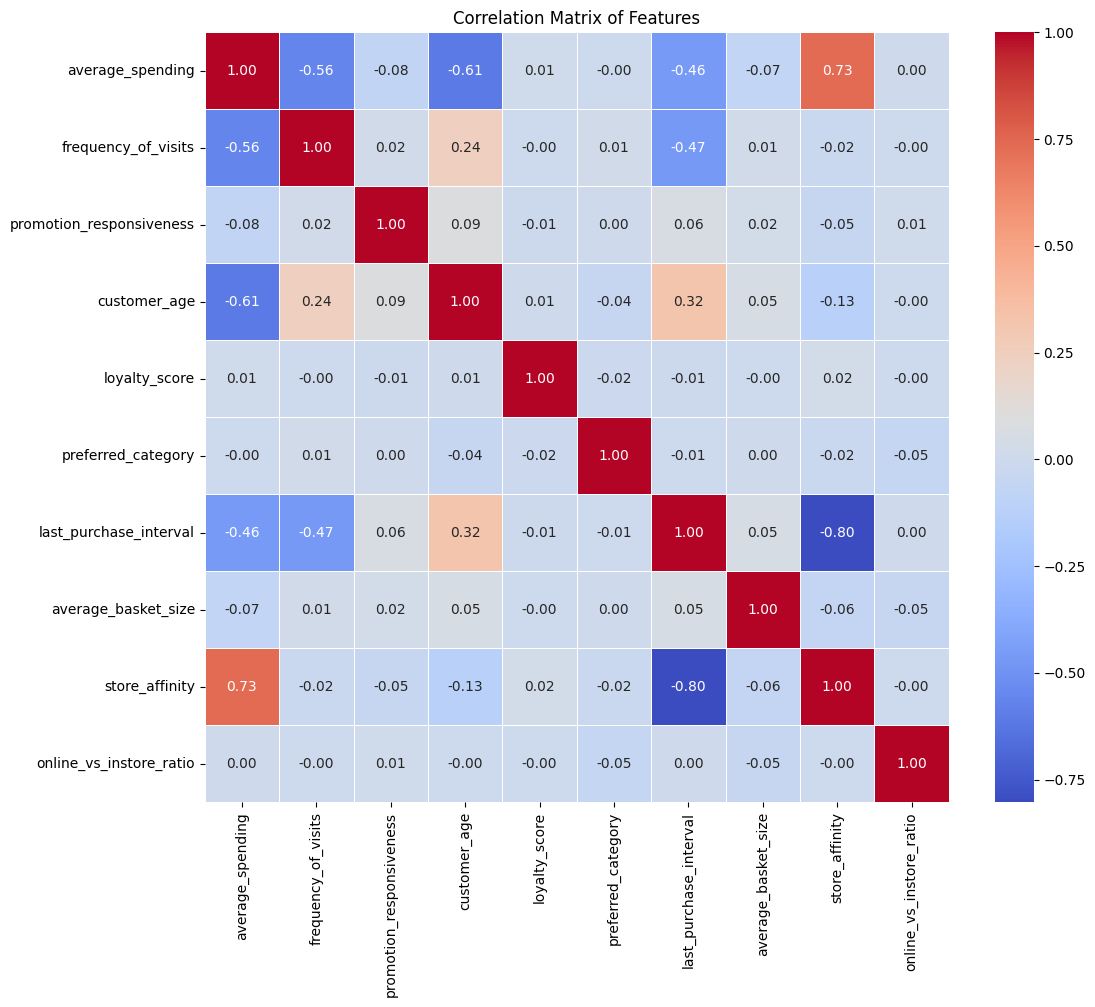

In [318]:

import seaborn as sns


df2 = pd.read_csv("https://sharon.srworkspace.com/ml/datasets/hw1/customers.csv")
correlation_matrix = df2.drop(columns=['label']).corr()  # Drop the label column before computing the correlation

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()




Adjust the data according to your decision and print again the train and test for both models.

In [319]:
# Change here the train and the test according to the feature you chose to remove
x_train_new = np.delete(x_train, 8, axis=1)
x_test_new = np.delete(x_test, 8, axis=1)



dict1 = {'GB': [], 'GNB': []}

accs = classify_point_gaussian_bayes(train=x_train_new, test=x_train_new)
dict1['GB'].append(np.count_nonzero(accs == y_train) / len(y_train))

accs = classify_point_gaussian_bayes(train=x_train_new, test=x_test_new)
dict1['GB'].append(np.count_nonzero(accs == y_test) / len(y_test))

accs = classify_point_gaussian_naive_bayes(train=x_train_new, test=x_train_new)
dict1['GNB'].append(np.count_nonzero(accs == y_train) / len(y_train))

accs = classify_point_gaussian_naive_bayes(train=x_train_new, test=x_test_new)
dict1['GNB'].append(np.count_nonzero(accs == y_test) / len(y_test))

df = pd.DataFrame(dict1, columns=['GB', 'GNB'], index=['train', 'test'])
print(df)

          GB     GNB
train  0.865  0.8325
test   0.840  0.8050


(Optional) Run the boundaries plotting for train and test with gaussian bayes.<br/>It will show the decision boundaries as saw in the lectures (do not modify it).

(12840, 10)


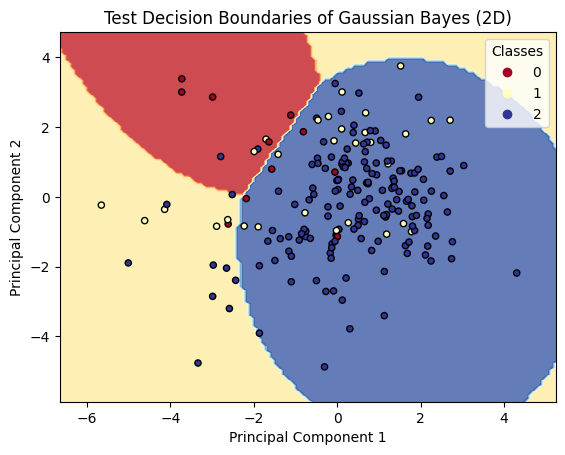

In [320]:
from sklearn.decomposition import PCA
from tqdm import tqdm

# Reduce the dimensionality of the data to 2 using PCA
pca = PCA(n_components=2)
pca.fit_transform(x_train)
X_reduced = pca.transform(x_test)

# Create a grid of points for visualization in the reduced 2D space
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Use the GNB model to predict class labels for the grid points in the original 13D space
grid_points = pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
print(grid_points.shape)
Z = classify_point_gaussian_naive_bayes(x_train, grid_points)
Z = Z.reshape(xx.shape)

# Plot the decision boundaries and the data points in the reduced 2D space
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k', s=20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Add a legend
handles, labels = scatter.legend_elements()
plt.legend(handles, labels, title='Classes')

plt.title('Test Decision Boundaries of Gaussian Bayes (2D)')
plt.show()

## Question 3 - Naive Bayes
In this problem, you’ll implement a basic Naïve Bayes classifier, and use it to predict the category for article news.

We will have to classify sentences into 5 categories, <b>but could be any number.</b><br/>
The categories are {"tech", "business", "sport", "entertainment", "politics"}.

<b>Warning:</b> I haven't personally looked at all the data here. Even though the data is taken from a ML databases site, accept my apologies if there are any offensive sentences.


import libarires

In [321]:
import numpy as np
import pandas as pd
import math
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import math

Implement the function. It reads all articles from file and returns the following data structures: <br/>
•	texall - list of documents; each entry corresponds to an article which is an array of words. <br/>
•	lbAll list of articles' labels.<br/>
•	voc - set of all distinct words in the entire data.<br/>
•	cat - set of article categories.


In [322]:
def readTrainData(file_name):
    df = pd.read_csv(file_name, header=None)  # Read without headers

    # Rename columns
    df.columns = ['label', 'text']

    # Extract list of documents (split into words)
    texAll = [text.split() for text in df['text']]

    # Extract labels of all articles
    lbAll = df['label'].tolist()

    # Create a set of all distinct words in the data
    voc = set(word for article in texAll for word in article)

    # Create a set of all unique article categories
    cat = set(lbAll)

    return texAll, lbAll, voc, cat



Implement the function, which computes and returns the probabilities (on the train set):<br/>
- $P_w$ - a matrix of class-conditional probabilities, $p(x|w_i)$
- $P$ - a vector of class priors, $p(w_i)$

Make sure you deal with the case of word that appears in voc but not in class $w$.

Note: this function does not need any inputs, as the train (and test) are defined below.

In [323]:


def learn_NB_text():
    # Use the necessary global variables
    global texAll_train, lblAll_train, voc, cat

    # Initialize word-category conditional probabilities with Laplace smoothing
    word_probabilities = {word: {category: 1 for category in cat} for word in voc}
    class_counts = Counter(lblAll_train)

    # Initialize total word count for each class
    class_word_totals = {category: 0 for category in cat}
    for document, label in zip(texAll_train, lblAll_train):
        class_word_totals[label] += len(document)

    # Update word-category conditional probabilities based on the training data
    for document, label in zip(texAll_train, lblAll_train):
        for word in document:
            if word in voc:
                word_probabilities[word][label] += 1

    # Apply Laplace smoothing to the word probabilities
    for word in word_probabilities:
        for category in word_probabilities[word]:
            word_probabilities[word][category] /= (class_word_totals[category] + len(voc))  # Laplace smoothing

    # Calculate probabilities for each category
    total_documents = len(lblAll_train)
    for category in class_counts:
        class_counts[category] /= total_documents

    return word_probabilities, class_counts


Implement fhe function that classifies all articles from the test set and computes the success rate.<br/>
Iterate over all articles of test and for each article find the most probable category.
<br/><br/>
Note1: Multiplying lots of probabilities, which are between 0 and 1, can result in floating-point underflow. Since log(xy) = log(x) + log(y), it is better to perform all computations by summing logs of probabilities rather than multiplying probabilities. <br/>Class with highest final un-normalized log probability score is still the most probable.


In [324]:


def ClassifyNB_text(word_probabilities, class_counts):
    # Use the necessary global variables
    global texAll_test, lblAll_test

    # list to store the predicted labels
    predicted_labels = []

    # Classify each test document
    for document in texAll_test:
        # Initialize log probabilities for each class based on class priors
        log_probs = {category: math.log(class_counts[category]) for category in class_counts}

        # Update log probabilities based on words in the document
        for word in document:
            if word in word_probabilities:
                for category in word_probabilities[word]:
                    log_probs[category] += math.log(word_probabilities[word][category])

        # Select the class with the highest log probability
        predicted_label = max(log_probs, key=log_probs.get)
        predicted_labels.append(predicted_label)

    # Calculate the accuracy of the classification
    accuracy = sum(pred == true for pred, true in zip(predicted_labels, lblAll_test)) / len(lblAll_test)

    return accuracy


Read the files

In [325]:
TRAIN_FILE = 'https://sharon.srworkspace.com/ml/datasets/hw1/bbc_train.csv'
TEST_FILE = 'https://sharon.srworkspace.com/ml/datasets/hw1/bbc_test.csv'

texAll_train, lblAll_train, voc, cat = readTrainData(TRAIN_FILE)

# cats must be the same at train and test
# voc of test is irrelevant - we already trained on other voc.
texAll_test, lblAll_test, _, __ = readTrainData(TEST_FILE)

Train the model, classify it on the test and report the success rate

In [326]:
Pw, P = learn_NB_text()
acc_right = ClassifyNB_text(Pw, P)
print(acc_right)

0.9655688622754491


## Question 4 - KNN

You want to detect types into 6 types of stars by measuring their properties.

NASA gave you their dataset, including temperature, color, Spectral_Class and more. <br/> In addition, you aim to compare different distance metric to determine which one is the best for this data.

import libaries

In [327]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Load the data, print the first three rows<br/>
https://sharon.srworkspace.com/ml/datasets/hw1/Stars.csv

In [328]:
# Load the dataset from the provided URL or local file
url = "https://sharon.srworkspace.com/ml/datasets/hw1/Stars.csv"
df = pd.read_csv(url)

# Print the first three rows of the dataset
print(df.head(3))


   Temperature       L       R    A_M Color Spectral_Class  Type
0         3068  0.0024  0.1700  16.12   Red              M     0
1         3042  0.0005  0.1542  16.60   Red              M     0
2         2600  0.0003  0.1020  18.70   Red              M     0


Convert categorial features to discerete values

In [329]:
colors = df['Color'].unique()
for idx, color in enumerate(colors):
  df['Color'] = df['Color'].replace({color: idx})

spec_class = df['Spectral_Class'].unique()
for idx, spec in enumerate(spec_class):
  df['Spectral_Class'] = df['Spectral_Class'].replace({spec: idx})
df.head(3)

<ipython-input-329-b8eb6525d3a7>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Color'] = df['Color'].replace({color: idx})
<ipython-input-329-b8eb6525d3a7>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Spectral_Class'] = df['Spectral_Class'].replace({spec: idx})


,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.0024,0.1700,16.12,0,0,0
1,3042,0.0005,0.1542,16.60,0,0,0
2,2600,0.0003,0.1020,18.70,0,0,0


Check the correlation matrix between the features. <br/>
Which distance metric do you expect to work better: Euclidean distance, of the Mahalanobis distance? <br/>
<font color='red'>Looking at the correlation matrix, we can see that many features are strongly related to each other. Mahalanobis distance works better in this case because it takes these relationships into account. On the other hand, Euclidean distance treats all features as if they are independent, which doesn't work well when there are correlations. So, because of the correlations in this dataset, Mahalanobis distance should work better.</font>

In [330]:
correlation_matrix = df.corr()

# Print the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                Temperature         L         R       A_M     Color  \
Temperature        1.000000  0.393404  0.064216 -0.420261  0.535934   
L                  0.393404  1.000000  0.526516 -0.692619  0.199249   
R                  0.064216  0.526516  1.000000 -0.608728 -0.062509   
A_M               -0.420261 -0.692619 -0.608728  1.000000 -0.352271   
Color              0.535934  0.199249 -0.062509 -0.352271  1.000000   
Spectral_Class     0.527404  0.409473  0.001467 -0.433673  0.701516   
Type               0.411129  0.676845  0.660975 -0.955276  0.409732   

                Spectral_Class      Type  
Temperature           0.527404  0.411129  
L                     0.409473  0.676845  
R                     0.001467  0.660975  
A_M                  -0.433673 -0.955276  
Color                 0.701516  0.409732  
Spectral_Class        1.000000  0.477165  
Type                  0.477165  1.000000  


Split the data to 80% train and 20% test, with random state 21. <br/>
Make sure to maintain the dataset balanced, using stratify=y, in train_test_split method. <br/> You can check the balance using df.value_counts().<br/>


In [331]:
# Convert DataFrame to NumPy array
arr = df.values

# Extract features and target variable
X_data = arr[:, :-1]  # All columns except the last one features
y_data = arr[:, -1]   # Last column target

# Split data into training and testing sets (80%-20%) with random_state=21
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=21, stratify=y_data
)
df.value_counts()


,,,,,,,count
Temperature,L,R,A_M,Color,Spectral_Class,Type,
1939,0.000138,0.1030,20.060,0,0,0,1
2600,0.000300,0.1020,18.700,0,0,0,1
10930,783930.000000,25.0000,-6.224,6,4,4,1
10980,0.000740,0.0087,11.190,1,1,2,1
11000,170000.000000,1779.0000,-9.900,7,1,5,1
...,...,...,...,...,...,...,...
3553,145000.000000,1324.0000,-11.030,0,0,5,1
3570,320000.000000,1480.0000,-7.580,0,0,5,1
3574,200000.000000,89.0000,-5.240,0,0,4,1


Implement the functions 'Euclidian', 'Manhattan'. <br/>
Those functions get train and test datasets ($m\times d, n\times d$) and returns the distance metric sized $m \times n$, based on the distance metric.<br/>
Reminder: Manhattan distance is $d(x,y)=\sum_{i=1}^d |x_i-y_i|$, d is the features number.


In [333]:
# Euclidean Distance function
def Euclidean(test, data):
    distances = np.zeros((test.shape[0], data.shape[0]))  # Initialize the distance array
    for i in range(test.shape[0]):  # Loop over each test sample
        for j in range(data.shape[0]):  # Loop over each training sample
            diff = test[i] - data[j]  # Difference between the test and training samples
            distances[i, j] = np.sqrt(np.sum(diff**2))  # Euclidean distance formula
    return distances

# Manhattan Distance function
def Manhattan(test, data):
    distances = np.zeros((test.shape[0], data.shape[0]))  # Initialize the distance array
    for i in range(test.shape[0]):  # Loop over each test sample
        for j in range(data.shape[0]):  # Loop over each training sample
            diff = np.abs(test[i] - data[j])  # Absolute difference between test and training samples
            distances[i, j] = np.sum(diff)  # Manhattan distance formula
    return distances

def Mahalanobis(test, data):
  distances = np.zeros((test.shape[0], data.shape[0]))
  covariance_matrix_data = np.cov(data, rowvar=False)

  # Calculate the Mahalanobis distances
  for i in range(test.shape[0]):
      for j in range(data.shape[0]):
          diff =  test[i] - data[j]
          distances[i, j] = np.sqrt(np.dot(np.dot(diff, np.linalg.inv(covariance_matrix_data)), diff.T))
  return distances

Implement the function kNN_classify that returns array sized m, which are the predictions for the m test samples.

In [334]:
def kNN_classify(data, labels, test, k, metric='Euclidian'):
  # Check which metric to use for distance calculation
    if metric == 'Euclidean':
        distances = Euclidean(test, data)  # Compute Euclidean distances
    elif metric == 'Manhattan':
        distances = Manhattan(test, data)  # Compute Manhattan distances
    elif metric == 'Mahalanobis':
        distances = Mahalanobis(test, data)  # Compute Mahalanobis distances

 # Initialize a list for storing predictions
    predictions = []

    # For each test sample, find the k nearest neighbors and predict the label
    for i in range(test.shape[0]):  # Loop through each test sample
        # Get the indices of the k smallest distances (nearest neighbors)
        nearest_neighbor_indices = distances[i].argsort()[:k]

        # Get the labels of the k nearest neighbors
        nearest_neighbor_labels = labels[nearest_neighbor_indices]

        # Ensure labels are integers for np.bincount() to work properly
        nearest_neighbor_labels = nearest_neighbor_labels.astype(int)

        # Find the most common label among the k nearest neighbors
        most_common_label = np.bincount(nearest_neighbor_labels).argmax()  # Most frequent label

        # Append the predicted label for this test sample
        predictions.append(most_common_label)

    return np.array(predictions)

Look at the plots for different k values and compare those metrics.
- Which metric was better? What might cause it?
- If the "test" was "validation", which k would you choose? <br/>
<font color='red'>The metric that performed better is Manhattan. This could be due to how Manhattan distance captures the relationships between features, especially in cases where features are not independently scaled or have different ranges. If the "test" was "validation", I would choose k = 7, as it shows the highest accuracy across both metrics.






</font>

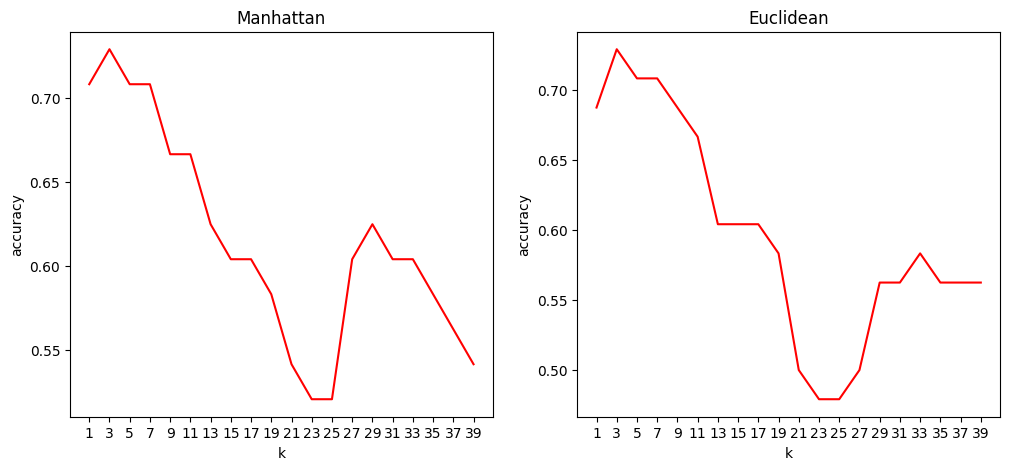

In [335]:
metrics = ['Manhattan', 'Euclidean']
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for idx, metric in enumerate(metrics):

  ks = np.arange(1, 41, 2)
  accs = []
  for k in ks:
    c = kNN_classify(X_train, y_train, X_test, k, metric)
    accs.append(np.mean(c == y_test))


  axs[idx % 2].plot(ks, accs, color='red')
  axs[idx % 2].set_xlabel('k')
  axs[idx % 2].set_ylabel('accuracy')
  axs[idx % 2].set_title(metric)
  axs[idx % 2].set_xticks(ks)
plt.show()

The Mahalanobis distance metric is already implemented to you. <br/>Run the following code and answer: Which gives better accuracy?<br/>
<font color='red'>The Mahalanobis distance gives the best accuracy when k is small, around k = 1 or k = 3. As k increases, accuracy decreases, which suggests that smaller values of k capture more relevant neighbors, while larger values might reduce accuracy due to averaging distant neighbors. Therefore, k = 1 or k = 3 is the best choice.</font>

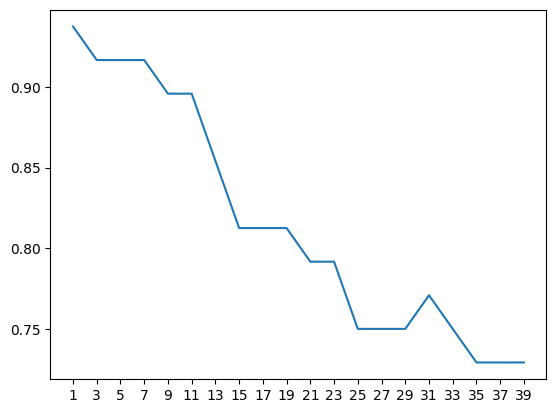

In [336]:
ks = np.arange(1, 41, 2)
accs = []

for k in ks:
    c = kNN_classify(X_train, y_train, X_test, k, 'Mahalanobis')
    accs.append(np.mean(c == y_test))

plt.plot(ks, accs)
plt.xticks(ks)
plt.show()

### Thats it!
If you choose to continue, 5 pts bonus!

We are going to classify the fashion MNIST data.<br/>
First, load the the train and test from:
- https://sharon.srworkspace.com/ml/datasets/hw1/fashion-mnist_train.csv
- https://sharon.srworkspace.com/ml/datasets/hw1/fashion-mnist_test.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

helper

In [ ]:
data = pd.read_csv('https://sharon.srworkspace.com/ml/datasets/hw1/fashion-mnist_train.csv').to_numpy()
X_train = data[:,1:]
y_train = data[:,0]

data2 = pd.read_csv('https://sharon.srworkspace.com/ml/datasets/hw1/fashion-mnist_test.csv').to_numpy()
X_test = data2[:,1:]
y_test = data2[:,0]

dispaly some random image

In [ ]:
idx = np.random.randint(len(X_train))
plt.imshow(X_train[idx].reshape(28,28), cmap='gray')
plt.show()

Use some google to search for appropriate distance metric that should classify correctly images. From what you read, explain yourselves, why is it a good distance metric?<br/>
<font color='red'>Write here your answer and explain it</font>

Now, use the sklearn package of KNN with the metric you chose and print a graph of accuracy on the test, as function of k.

Were you correct?

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

ks = np.arange(1, 30, 2)
accs = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, metric='WhatYouFoundOnGoogle')
    knn.fit(X_train, y_train)

    c = knn.predict(X_test)
    accs.append()   # Implement here

plt.plot(ks, accs)
plt.xticks(ks)
plt.show()